# Building an optimal portfolio from scratch using Markowitz theory, Python, and real NSE data from SBI and ITC.

## I Had ₹1,00,000 and Two Stocks. Math Told Me Exactly How to Split It.

**Building an optimal portfolio from scratch using Markowitz theory, Python, and real NSE data.**

---

Here’s a question that sounds simple but isn’t — if you had to invest in just two stocks, how would you split your money to achieve the best risk-adjusted return?

Most people go with their gut. Maybe a 50-50 split. Maybe they dump everything into whichever stock "feels" stronger. However, in 1952, Harry Markowitz answered this question with mathematics. His mean-variance optimization framework won him a Nobel Prize and changed how every institutional investor on the planet thinks about risk.

The core idea is simple: don’t just chase the highest return; find the combination of assets that provides the maximum return per unit of risk. The optimal split depends heavily on a single statistical metric: the correlation between the two stocks.

To demonstrate this, I selected two stocks from completely different sectors on the NSE — **State Bank of India (SBI)** from banking and **ITC Limited (ITC)** from consumer goods — pulled 5 years of daily historical data, and built the portfolio optimizer from scratch in Python.

### How We'll Build This
Here is the step-by-step blueprint for our analysis:
1. **Gathering the Data**: We'll fetch 5 years of daily price data directly from Yahoo Finance and compute daily log returns.
2. **Calculating Risk & Return**: We'll calculate the annualized expected return, volatility, covariance, and correlation from scratch.
3. **Simulating allocations**: We'll sweep through different weight combinations to see how risk and return change dynamically.
4. **Mapping the Efficient Frontier**: We'll plot the Efficient Frontier and mathematically locate the Minimum Variance Portfolio (the allocation with the lowest possible risk).

### The Cheat Sheet: Key Terms
- **Expected Return (μ)**: The average annualized payoff estimated from historical data.
- **Volatility (σ)**: The standard deviation of daily returns. In this framework, volatility represents risk.
- **Correlation (ρ)**: A metric from -1 to +1 showing how two stocks move together.
- **Covariance**: A measure of joint variability. Covariance = ρ × σ₁ × σ₂.
- **Weight (w)**: The percentage of capital allocated to a stock (e.g., 0.6 = ₹60,000 out of ₹1,00,000).
- **Efficient Frontier**: The boundary of optimal portfolios offering the highest expected return for a defined level of risk.
- **Naive Volatility**: A simple weighted average of individual volatilities that ignores correlation.

### Assumptions of the Model
This analysis operates within the classic 1952 Markowitz framework:
- Returns are normally distributed.
- Investors are rational and risk-averse.
- There are no transaction costs, brokerage, or taxes.
- Historical returns and covariances serve as reasonable estimators for future performance.

### Customizing Tickers & Installation
If you want to run this analysis on different stocks of your choice (e.g., Reliance and TCS), you can change the ticker variables in the code block below.

First, run the cell below to install the necessary libraries (`yfinance`, `numpy`, `matplotlib`) if they are not already installed in your environment.

In [1]:
# Run this cell to install required libraries
!pip install yfinance numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Step 1: Pulling Price Data

We retrieve 5 years of daily adjusted close prices for our chosen stocks. Adjusted close prices account for corporate actions like stock splits and dividends, ensuring our returns accurately reflect investor experience.

In [2]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# Define the tickers to analyze. Change these to get observations for other stocks!
# Use the '.NS' suffix for National Stock Exchange of India (e.g., 'RELIANCE.NS', 'TCS.NS')
ticker_1 = "SBIN.NS"
ticker_2 = "ITC.NS"

data_1 = yf.download(ticker_1, period="5y", interval="1d", auto_adjust=True)
data_2 = yf.download(ticker_2, period="5y", interval="1d", auto_adjust=True)

# Convert single-column DataFrame to Series and drop NaN values
prices_1 = data_1["Close"].squeeze().dropna()
prices_2 = data_2["Close"].squeeze().dropna()

# Align the indices to keep only common trading days
common_dates = prices_1.index.intersection(prices_2.index)
prices_1 = prices_1.loc[common_dates]
prices_2 = prices_2.loc[common_dates]

print(f"Stock 1: {ticker_1}")
print(f"Stock 2: {ticker_2}")
print(f"Date range: {common_dates[0].date()} to {common_dates[-1].date()}")
print(f"Trading days: {len(common_dates)}")
print("\nFirst 5 days of adjusted close prices:")
print(f"{'Date':<15} {ticker_1:>12} {ticker_2:>12}")
print("-" * 45)
for i in range(5):
    d = common_dates[i].strftime("%Y-%m-%d")
    print(f"{d:<15} {float(prices_1.iloc[i]):>12.2f} {float(prices_2.iloc[i]):>12.2f}")


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

Stock 1: SBIN.NS
Stock 2: ITC.NS
Date range: 2021-07-19 to 2026-07-17
Trading days: 1238

First 5 days of adjusted close prices:
Date                 SBIN.NS       ITC.NS
---------------------------------------------
2021-07-19            391.42       163.58
2021-07-20            385.02       162.83
2021-07-22            386.07       162.99
2021-07-23            392.34       167.24
2021-07-26            387.21       166.26


# Step 2: Computing Log Returns

We compute daily log returns using the formula:
rₜ = ln(Pₜ / Pₜ₋₁)

Log returns are widely preferred in quantitative finance because they are time-additive (daily returns sum to weekly or annual returns), symmetric (a +5% return followed by a -5% return cancels out exactly), and tend to align more closely with normal distributions.

In [3]:
# Compute daily log returns
p1 = prices_1.values.flatten()
p2 = prices_2.values.flatten()

log_returns_1 = np.log(p1[1:] / p1[:-1])
log_returns_2 = np.log(p2[1:] / p2[:-1])
n = len(log_returns_1)

print(f"Total return observations: {n}")
print("\nFirst 5 days of log returns:")
print(f"{'Day':<6} {ticker_1 + ' Return':>16} {ticker_2 + ' Return':>16}")
print("-" * 42)
for i in range(5):
    print(f"{i+1:<6} {log_returns_1[i]:>16.6f} {log_returns_2[i]:>16.6f}")

Total return observations: 1237

First 5 days of log returns:
Day      SBIN.NS Return    ITC.NS Return
------------------------------------------
1             -0.016494        -0.004583
2              0.002728         0.000967
3              0.016100         0.025752
4             -0.013143        -0.005903
5              0.015588        -0.011910


# Step 3: Expected Return, Volatility, Covariance & Correlation

Next, we calculate the statistics required for the Markowitz model:
- **Annualized expected return**: $\mu = \bar{r}_{\text{daily}} \times 252$
- **Annualized volatility**: $\sigma = \sigma_{\text{daily}} \times \sqrt{252}$
- **Correlation**: $\rho = \frac{\text{Cov}(r_1, r_2)}{\sigma_1 \cdot \sigma_2}$

where 252 represents the typical number of trading days in a year. We use the arithmetic mean of log returns as the unbiased estimator of single-period expected return.

In [4]:
# Calculate expected returns and standard deviations from scratch
mean_1 = np.sum(log_returns_1) / n
mean_2 = np.sum(log_returns_2) / n

# Daily variance with Bessel's correction (ddof=1)
var_daily_1 = np.sum((log_returns_1 - mean_1) ** 2) / (n - 1)
var_daily_2 = np.sum((log_returns_2 - mean_2) ** 2) / (n - 1)
std_daily_1 = np.sqrt(var_daily_1)
std_daily_2 = np.sqrt(var_daily_2)

# Daily covariance
cov_daily = np.sum((log_returns_1 - mean_1) * (log_returns_2 - mean_2)) / (n - 1)

# Correlation coefficient
rho = cov_daily / (std_daily_1 * std_daily_2)

# Annualize metrics
mu_1 = mean_1 * 252
mu_2 = mean_2 * 252
sigma_1 = std_daily_1 * np.sqrt(252)
sigma_2 = std_daily_2 * np.sqrt(252)
cov_annual = cov_daily * 252

print("=============================================")
print("        ANNUALIZED PORTFOLIO METRICS")
print("=============================================")
print(f"{'Metric':<20} {ticker_1:>10} {ticker_2:>10}")
print("-" * 45)
print(f"{'Expected Return':<20} {mu_1:>10.2%} {mu_2:>10.2%}")
print(f"{'Volatility (Risk)':<20} {sigma_1:>10.2%} {sigma_2:>10.2%}")
print("-" * 45)
print(f"Correlation (ρ):     {rho:.4f}")
print(f"Covariance (ann.):   {cov_annual:.6f}")
print("=============================================")

        ANNUALIZED PORTFOLIO METRICS
Metric                  SBIN.NS     ITC.NS
---------------------------------------------
Expected Return          19.99%     11.00%
Volatility (Risk)        24.93%     20.05%
---------------------------------------------
Correlation (ρ):     0.2802
Covariance (ann.):   0.014002


### Interpreting Correlation (ρ)

The correlation coefficient $\rho$ describes the relationship between the two assets:
- **$\rho = 1$**: Perfect positive correlation. The stocks move in perfect lockstep; no risk reduction is possible.
- **$\rho = 0$**: No linear relationship. The assets move independently.
- **$\rho = -1$**: Perfect negative correlation. The assets move in opposite directions; risk can be completely eliminated.

A low correlation coefficient indicates partial independence, which creates the diversification benefit when assets are combined.

# Step 4: Building the Portfolio

Suppose we have ₹1,00,000 to allocate. We assign a weight $w$ to Stock 1 and the remaining fraction $(1-w)$ to Stock 2.

### Portfolio Expected Return
The expected return of a two-asset portfolio is a simple weighted average of individual returns:
$$\mu_p = w \cdot \mu_1 + (1-w) \cdot \mu_2$$

Expected return scales linearly with allocation. There is no mathematical interaction here.

### Portfolio Volatility: Where Diversification Happens
The actual portfolio variance is given by:
$$\sigma_p^2 = w^2 \sigma_1^2 + (1-w)^2 \sigma_2^2 + 2w(1-w) \cdot \rho \cdot \sigma_1 \cdot \sigma_2$$

The third term reflects the correlation $\rho$ between the two assets. As long as correlation is less than 1, the portfolio volatility is lower than a naive weighted average. This reduction in risk is the direct result of diversification.

# Step 5: Portfolio Return & Risk at Different Allocations

Let us simulate the portfolio statistics across various weight combinations to see the impact of diversification.

In [5]:
# Sweep weights from 0% to 100%
sample_weights = np.linspace(0, 1, 21)

print("==========================================================================")
print(f"             PORTFOLIO METRICS AT VARIOUS ALLOCATIONS ({ticker_1} + {ticker_2})")
print("==========================================================================")
print(f"  {f'w({ticker_1})':<12} {f'1-w({ticker_2})':<12} {'Return':>10} {'Actual Vol':>12} {'Naive Vol':>12} {'Benefit':>10}")
print("-" * 76)

for w in sample_weights:
    ret = w * mu_1 + (1 - w) * mu_2
    
    # Portfolio variance formula
    var = (w ** 2) * (sigma_1 ** 2) + \
          ((1 - w) ** 2) * (sigma_2 ** 2) + \
          2 * w * (1 - w) * rho * sigma_1 * sigma_2
    volatility_actual = np.sqrt(var)
    volatility_naive = w * sigma_1 + (1 - w) * sigma_2
    benefit = volatility_naive - volatility_actual
    
    print(f"  {w:<12.0%} {1-w:<12.0%} {ret:>10.2%} {volatility_actual:>11.2%} {volatility_naive:>11.2%} {benefit:>9.2%}")

print("-" * 76)
print("  Benefit = Naive Volatility - Actual Volatility (Risk reduction from diversification)")
print("==========================================================================")

             PORTFOLIO METRICS AT VARIOUS ALLOCATIONS (SBIN.NS + ITC.NS)
  w(SBIN.NS)   1-w(ITC.NS)      Return   Actual Vol    Naive Vol    Benefit
----------------------------------------------------------------------------
  0%           100%             11.00%      20.05%      20.05%     0.00%
  5%           95%              11.45%      19.43%      20.29%     0.86%
  10%          90%              11.90%      18.89%      20.54%     1.64%
  15%          85%              12.35%      18.44%      20.78%     2.34%
  20%          80%              12.80%      18.08%      21.02%     2.94%
  25%          75%              13.25%      17.82%      21.27%     3.45%
  30%          70%              13.70%      17.65%      21.51%     3.86%
  35%          65%              14.15%      17.60%      21.76%     4.16%
  40%          60%              14.60%      17.64%      22.00%     4.36%
  45%          55%              15.05%      17.80%      22.24%     4.45%
  50%          50%              15.50%      

# Step 6: The Efficient Frontier & Minimum Variance Portfolio

By plotting portfolio volatility ($\sigma_p$) on the x-axis and portfolio expected return ($\mu_p$) on the y-axis for all possible weight combinations, we map the **Efficient Frontier**.

This curve is a hyperbola that bows to the left. The leftmost point on this curve is the **Minimum Variance Portfolio (MVP)**, which represents the allocation yielding the absolute lowest portfolio volatility.

For a two-asset portfolio, the risk-minimizing weight $w^*$ has a closed-form analytical solution:
$$w^* = \frac{\sigma_2^2 - \text{Cov}}{\sigma_1^2 + \sigma_2^2 - 2 \cdot \text{Cov}}$$

Let's calculate this value and plot the Efficient Frontier.

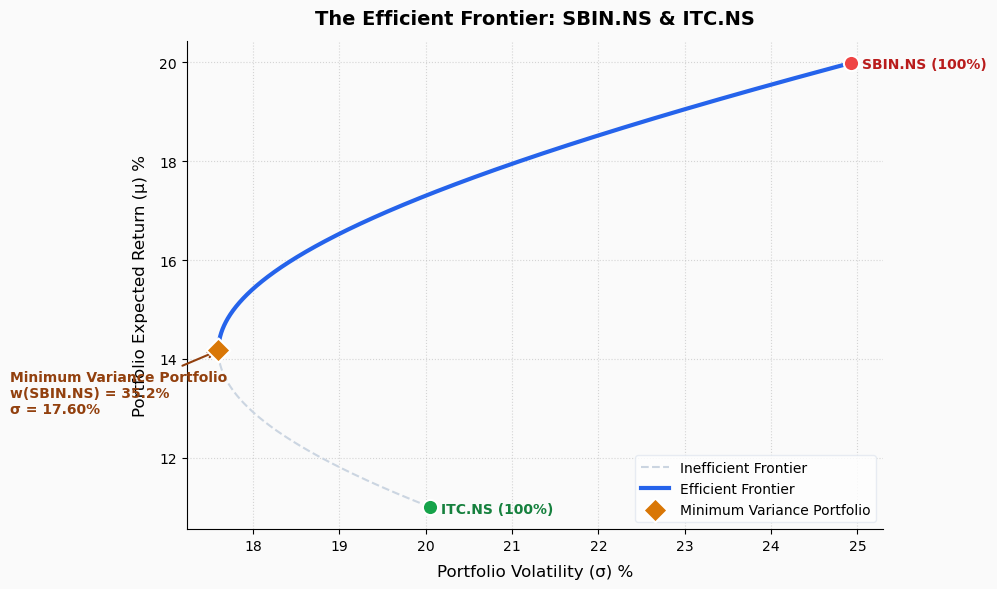

        MINIMUM VARIANCE PORTFOLIO STATS
Optimal Allocation w(SBIN.NS):  35.24%
Optimal Allocation w(ITC.NS):  64.76%
Expected Annualized Return:   14.17%
Expected Annualized Volatility: 17.60%


In [6]:
# Analytical Minimum Variance Portfolio (MVP)
var_1 = sigma_1 ** 2
var_2 = sigma_2 ** 2
w_min_var = (var_2 - cov_annual) / (var_1 + var_2 - 2 * cov_annual)

ret_min_var = w_min_var * mu_1 + (1 - w_min_var) * mu_2
var_min_var = (w_min_var ** 2) * var_1 + \
              ((1 - w_min_var) ** 2) * var_2 + \
              2 * w_min_var * (1 - w_min_var) * cov_annual
vol_min_var = np.sqrt(var_min_var)

# Generate efficient frontier curve points
num_portfolios = 1000
weights = np.linspace(0, 1, num_portfolios)
port_returns = weights * mu_1 + (1 - weights) * mu_2
port_vars = (weights ** 2) * var_1 + \
            ((1 - weights) ** 2) * var_2 + \
            2 * weights * (1 - weights) * cov_annual
port_volatilities = np.sqrt(port_vars)

# Find index of Minimum Variance Portfolio on the sweep curve
min_vol_idx = np.argmin(port_volatilities)

# Plotting the Efficient Frontier
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

# Plot the inefficient portion (below Minimum Variance Portfolio)
ax.plot(port_volatilities[:min_vol_idx+1] * 100, port_returns[:min_vol_idx+1] * 100,
        color='#cbd5e1', linewidth=1.5, linestyle='--', label='Inefficient Frontier')

# Plot the efficient portion (above Minimum Variance Portfolio)
ax.plot(port_volatilities[min_vol_idx:] * 100, port_returns[min_vol_idx:] * 100,
        color='#2563eb', linewidth=3, label='Efficient Frontier')

# Highlight individual stocks
ax.scatter(sigma_1 * 100, mu_1 * 100, color='#ef4444', s=120, zorder=5, edgecolors='white', linewidth=1.5)
ax.annotate(f'{ticker_1} (100%)', (sigma_1 * 100, mu_1 * 100), fontsize=10, xytext=(8, -4), textcoords='offset points', color='#b91c1c', fontweight='bold')

ax.scatter(sigma_2 * 100, mu_2 * 100, color='#16a34a', s=120, zorder=5, edgecolors='white', linewidth=1.5)
ax.annotate(f'{ticker_2} (100%)', (sigma_2 * 100, mu_2 * 100), fontsize=10, xytext=(8, -4), textcoords='offset points', color='#15803d', fontweight='bold')

# Highlight Minimum Variance Portfolio
ax.scatter(vol_min_var * 100, ret_min_var * 100, color='#d97706', s=150, marker='D', zorder=6, edgecolors='white', linewidth=1.5, label='Minimum Variance Portfolio')
ax.annotate(f'Minimum Variance Portfolio\nw({ticker_1}) = {w_min_var:.1%}\nσ = {vol_min_var:.2%}',
            xy=(vol_min_var * 100, ret_min_var * 100),
            fontsize=10, fontweight='bold', color='#92400e',
            xytext=(-150, -45), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='#92400e', lw=1.5))

# Formatting
ax.set_xlabel('Portfolio Volatility (σ) %', fontsize=12, labelpad=8)
ax.set_ylabel('Portfolio Expected Return (μ) %', fontsize=12, labelpad=8)
ax.set_title(f'The Efficient Frontier: {ticker_1} & {ticker_2}', fontsize=14, fontweight='bold', pad=12)
ax.grid(True, linestyle=':', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='lower right', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')

plt.tight_layout()
plt.savefig("efficient_frontier_custom.png", dpi=150)
plt.show()

print("=============================================")
print("        MINIMUM VARIANCE PORTFOLIO STATS")
print("=============================================")
print(f"Optimal Allocation w({ticker_1}):  {w_min_var:.2%}")
print(f"Optimal Allocation w({ticker_2}):  {1 - w_min_var:.2%}")
print(f"Expected Annualized Return:   {ret_min_var:.2%}")
print(f"Expected Annualized Volatility: {vol_min_var:.2%}")
print("=============================================")

# Conclusion & Takeaways

If you want a portfolio with minimum risk so that you can sleep well at night, go with the **Minimum Variance Portfolio**. 

In future articles, we will try to optimize the returns and reduce risk even further by adding a risk-free asset, analyzing it using the Sharpe ratio and the Efficient Frontier curve.

### The Real Takeaway
The point of this article isn’t the specific weights or rupee amounts — it’s the **way of thinking**. Before Markowitz, investors evaluated assets in isolation: "Is this a good stock?" After Markowitz, the question became: "How does this stock interact with everything else I own?"

That shift — from evaluating assets to evaluating **combinations** — is the single most important idea in finance. And now you’ve built it from scratch.

---

*All code is available on [GitHub](https://github.com/itssDurgesh). Built with Python, NumPy, and Matplotlib. Data from Yahoo Finance via yfinance.*

**Let's Connect!**

- **LinkedIn**: [durgesh-verma-a60499338](https://www.linkedin.com/in/durgesh-verma-a60499338)
- **GitHub**: [itssDurgesh](https://github.com/itssDurgesh)

I write about quantitative finance, algorithmic trading, probability theory, machine learning, and building systems from first principles. I am still learning, and I will be happy to receive feedback and join discussions.